In [18]:
#Which image models are best?
! git clone --depth 1 https://github.com/rwightman/pytorch-image-models.git
%cd pytorch-image-models/results

C:\Users\modin\OneDrive\Documents\my-internshipML\pytorch-image-models\results\pytorch-image-models\results


Cloning into 'pytorch-image-models'...
Updating files:  42% (199/470)
Updating files:  43% (203/470)
Updating files:  44% (207/470)
Updating files:  45% (212/470)
Updating files:  46% (217/470)
Updating files:  47% (221/470)
Updating files:  48% (226/470)
Updating files:  49% (231/470)
Updating files:  50% (235/470)
Updating files:  51% (240/470)
Updating files:  52% (245/470)
Updating files:  53% (250/470)
Updating files:  54% (254/470)
Updating files:  55% (259/470)
Updating files:  56% (264/470)
Updating files:  57% (268/470)
Updating files:  58% (273/470)
Updating files:  59% (278/470)
Updating files:  60% (282/470)
Updating files:  61% (287/470)
Updating files:  62% (292/470)
Updating files:  63% (297/470)
Updating files:  64% (301/470)
Updating files:  65% (306/470)
Updating files:  66% (311/470)
Updating files:  67% (315/470)
Updating files:  68% (320/470)
Updating files:  69% (325/470)
Updating files:  70% (329/470)
Updating files:  71% (334/470)
Updating files:  72% (339/470)


In [2]:
import pandas as pd
df_results = pd.read_csv('results-imagenet.csv')

In [3]:
df_results['model_org'] = df_results['model'] 
df_results['model'] = df_results['model'].str.split('.').str[0]

In [4]:
def get_data(part, col):
    df = pd.read_csv(f'benchmark-{part}-amp-nhwc-pt111-cu113-rtx3090.csv').merge(df_results, on='model')
    df['secs'] = 1. / df[col]
    df['family'] = df.model.str.extract('^([a-z]+?(?:v2)?)(?:\d|_|$)')
    df = df[~df.model.str.endswith('gn')]
    df.loc[df.model.str.contains('in22'),'family'] = df.loc[df.model.str.contains('in22'),'family'] + '_in22'
    df.loc[df.model.str.contains('resnet.*d'),'family'] = df.loc[df.model.str.contains('resnet.*d'),'family'] + 'd'
    return df[df.family.str.contains('^re[sg]netd?|beit|convnext|levit|efficient|vit|vgg|swin')]

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\modin\AppData\Local\Temp\ipykernel_17836\2866262832.py:4: SyntaxWarning: invalid escape sequence '\d'
  df['family'] = df.model.str.extract('^([a-z]+?(?:v2)?)(?:\d|_|$)')


In [5]:
df = get_data('infer', 'infer_samples_per_sec')

In [6]:
import plotly.express as px
w,h = 1000,800

def show_all(df, title, size):
    return px.scatter(df, width=w, height=h, size=df[size]**2, title=title,
        x='secs',  y='top1', log_x=True, color='family', hover_name='model_org', hover_data=[size])

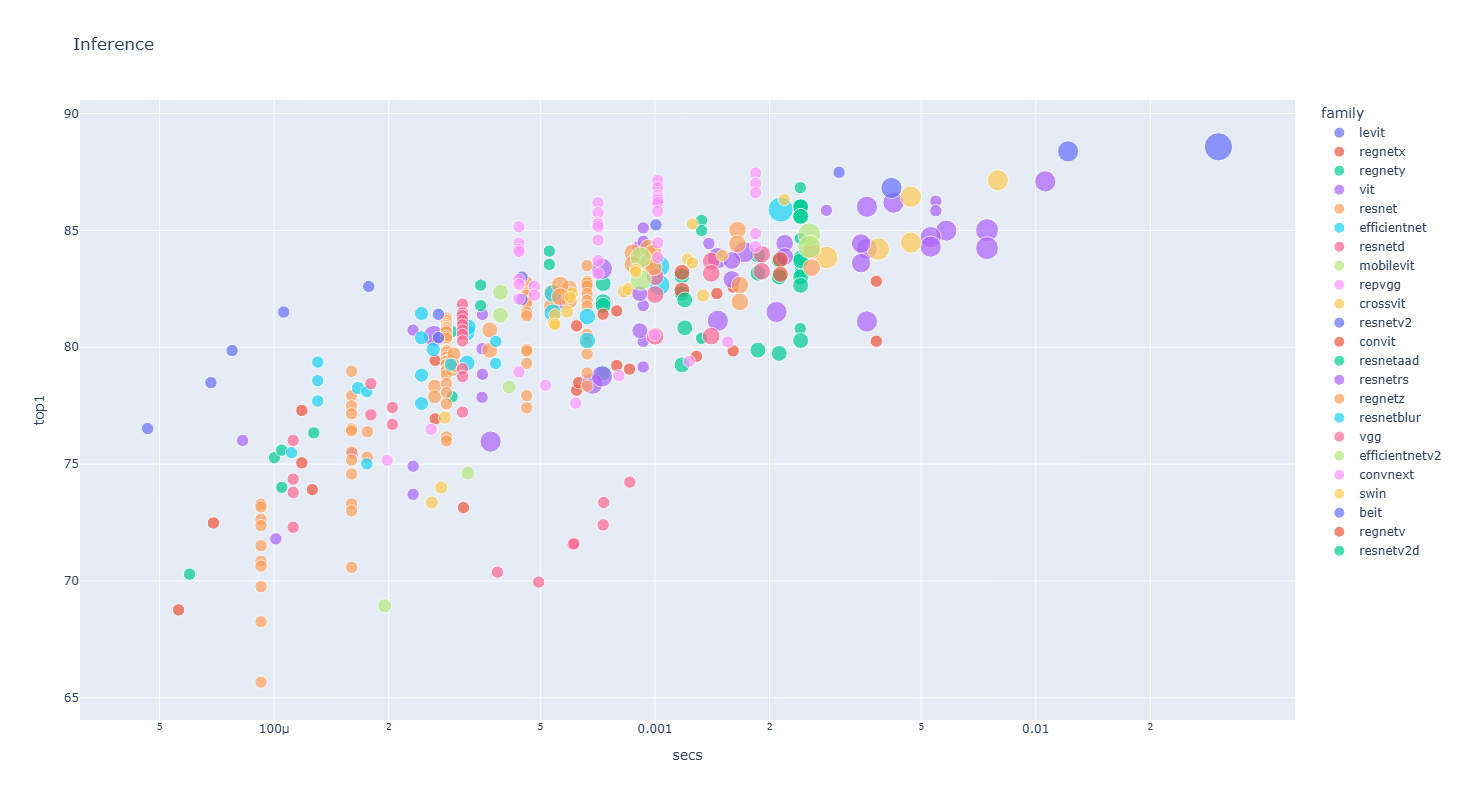

In [7]:
show_all(df, 'Inference', 'infer_img_size')

In [8]:
subs = 'levit|resnetd?|regnetx|vgg|convnext.*|efficientnetv2|beit|swin'

In [15]:
!pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB 393.8 kB/s eta 0:00:25
   ---------------------------------------- 0.1/9.5 MB 737.3 kB/s eta 0:00:13
    --------------------------------------- 0.2/9.5 MB 980.4 kB/s eta 0:00:10
    --------------------------------------- 0.2/9.5 MB 1.2 MB/s eta 0:00:08
   - -------------------------------------- 0.4/9.5 MB 1.4 MB/s eta 0:00:07
   -- ------------------------------------- 0.5/9.5 MB 1.7 MB/s eta 0:00:06
   -- ------------------------------------- 0.7/9.5 MB 2.0 MB/s eta 0:00:05
   --- ------------------------------------ 0.8/9.5 MB 1.9 MB/s eta 0:00:05
   ---- ----------------------------------- 1.0/9.5 MB 2.3 MB/s eta 0:00:04
   ----- ----------------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
def show_subs(df, title, size):
    df_subs = df[df.family.str.fullmatch(subs)]
    return px.scatter(df_subs, width=w, height=h, size=df_subs[size]**2, title=title,
        trendline="ols", trendline_options={'log_x':True},
        x='secs',  y='top1', log_x=True, color='family', hover_name='model_org', hover_data=[size])

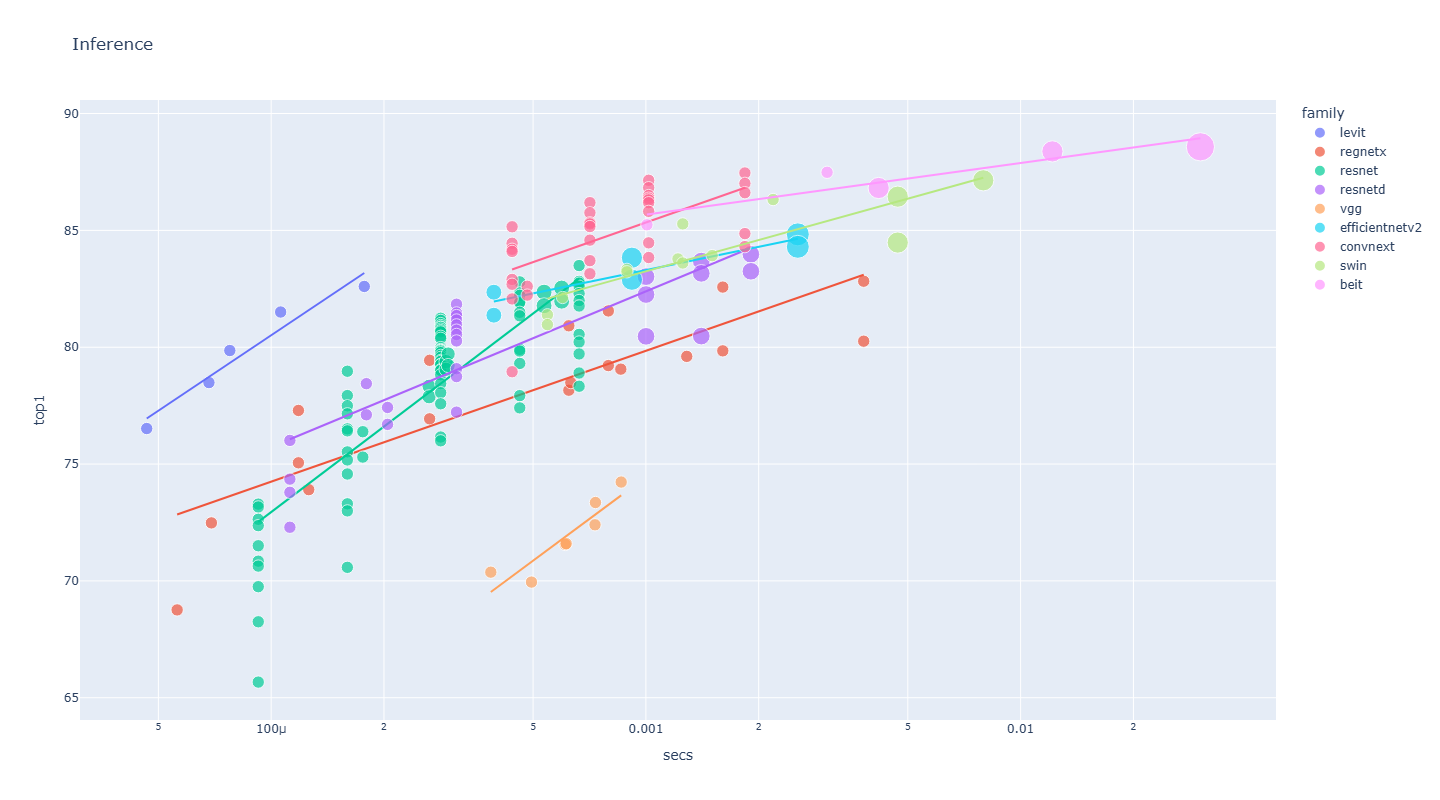

In [17]:
show_subs(df, 'Inference', 'infer_img_size')

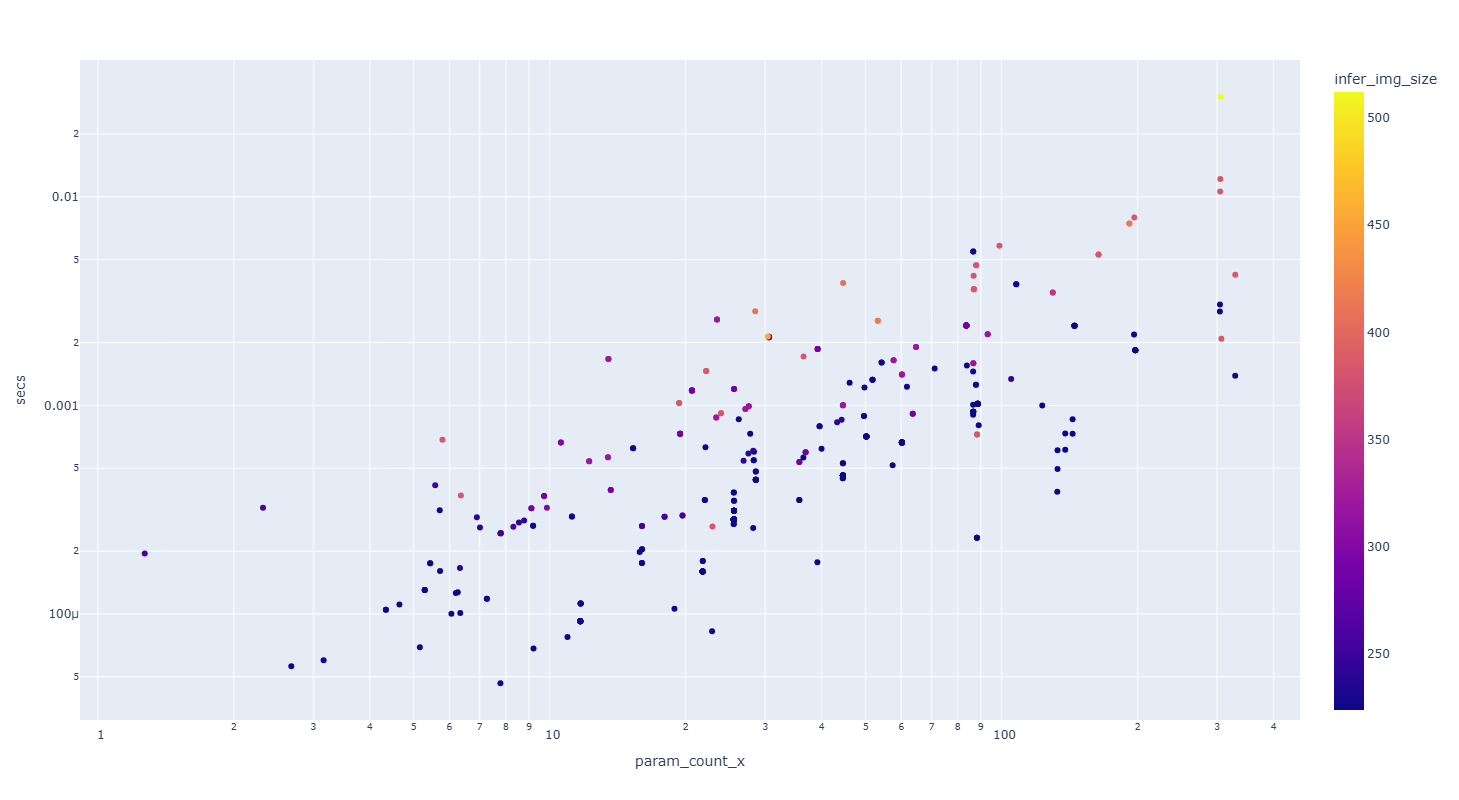

In [11]:
px.scatter(df, width=w, height=h,
    x='param_count_x',  y='secs', log_x=True, log_y=True, color='infer_img_size',
    hover_name='model_org', hover_data=['infer_samples_per_sec', 'family']
)

In [12]:
tdf = get_data('train', 'train_samples_per_sec')

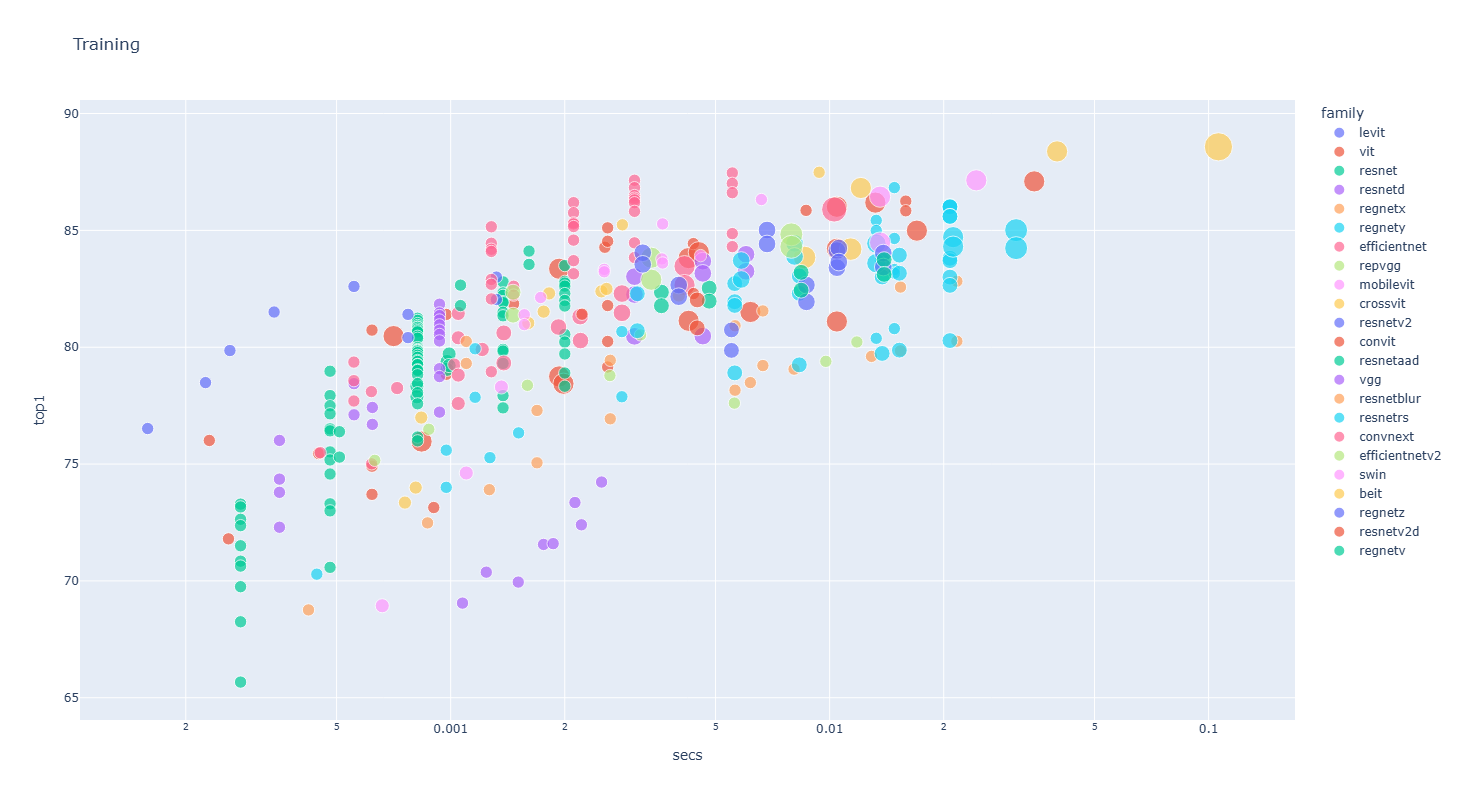

In [13]:
show_all(tdf, 'Training', 'train_img_size')

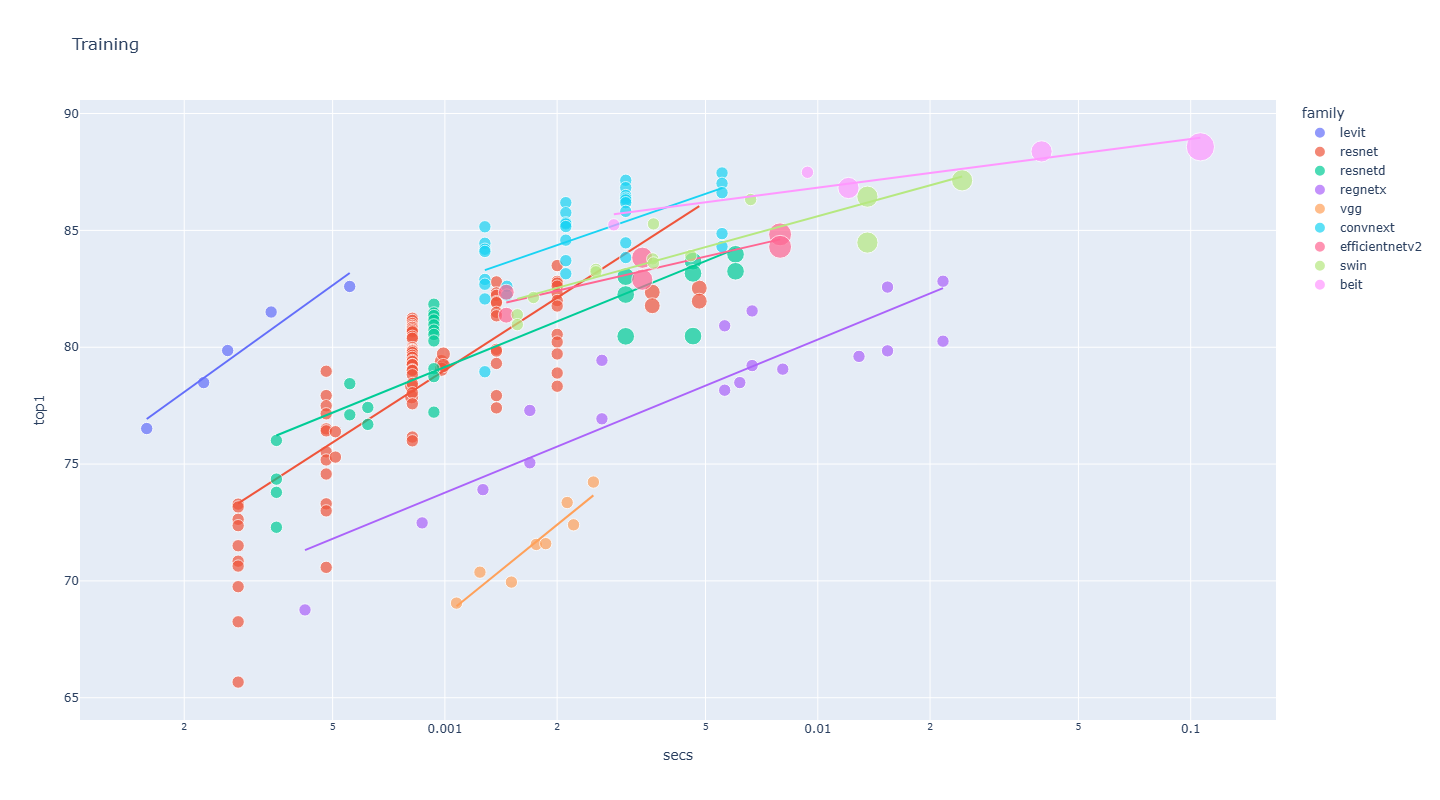

In [16]:
show_subs(tdf, 'Training', 'train_img_size')
